In [1]:
# Imports

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/dd4real2k/code/mlbh/GridZero


In [3]:
from python_scripts.data_to_bigquery import load_from_bigquery
from python_scripts.hgb_pipeline import hgb_train_preproc

In [4]:
# Load Dataset from BigQuery

client = bigquery.Client(project="gridzero-489711")

query = """
SELECT *
FROM `gridzero-489711.merged_set.full_feature_engineered_data_test`
ORDER BY datetime
"""

df = client.query(query).to_dataframe()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (148991, 31)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [5]:
target_col = "carbon_intensity_gco2_kwh"
datetime_col = "datetime"

In [6]:
df = hgb_train_preproc(
    df,
    target_col=target_col,
    datetime_col=datetime_col
)

print("Processed dataset shape:", df.shape)
df.head()

Processed dataset shape: (130766, 33)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520,carbon_roll_24h,carbon_roll_168h
0,2018-09-15 12:00:00+00:00,19.2,17.2,27.7,98.0,490.0,303.0,187.0,1024.2,0.0,...,-1.000000,-0.974928,-0.222521,-0.963471,-0.267814,211.0,255.0,270.0,239.625000,228.375000
1,2018-09-15 12:30:00+00:00,19.2,17.2,27.7,98.0,490.0,303.0,187.0,1024.2,0.0,...,-1.000000,-0.974928,-0.222521,-0.963471,-0.267814,212.0,255.0,249.0,243.875000,229.077381
2,2018-09-15 13:00:00+00:00,19.5,17.9,26.6,99.0,364.0,118.0,246.0,1023.8,0.0,...,-0.965926,-0.974928,-0.222521,-0.963471,-0.267814,214.0,248.0,262.0,247.708333,229.785714
3,2018-09-15 13:30:00+00:00,19.5,17.9,26.6,99.0,364.0,118.0,246.0,1023.8,0.0,...,-0.965926,-0.974928,-0.222521,-0.963471,-0.267814,215.0,239.0,251.0,251.250000,230.446429
4,2018-09-15 14:00:00+00:00,19.5,15.7,26.3,99.0,257.0,46.0,211.0,1023.4,0.0,...,-0.866025,-0.974928,-0.222521,-0.963471,-0.267814,203.0,235.0,257.0,254.208333,231.065476


In [7]:
# feature groups

weather_features = [
    "temperature_2m_c",
    "wind_speed_100m_ms",
    "wind_gusts_10m_ms",
    "cloud_cover_pct",
    "shortwave_radiation_wm2",
    "direct_radiation_wm2",
    "diffuse_radiation_wm2",
    "pressure_msl_hpa",
    "precipitation_mm"
]

generation_features = [
    "biomass",
    "fossil_gas",
    "fossil_hard_coal",
    "hydro_pumped_storage",
    "hydro_run_of_river_and_poundage",
    "nuclear",
    "other",
    "solar",
    "wind_offshore",
    "wind_onshore",
    "totaloutput_mw"
]

time_features = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos"
]

lag_rolling_features = [
    "carbon_lag_48",
    "carbon_lag_336",
    "carbon_roll_24h",
    "carbon_roll_168h"
]

In [8]:
# 3 Features sets

full_features = (
    weather_features +
    generation_features +
    time_features +
    lag_rolling_features
)

no_weather_features = (
    generation_features +
    time_features +
    lag_rolling_features
)

weather_only_features = weather_features

In [9]:
print("Missing from full_features:", [col for col in full_features if col not in df.columns])
print("Missing from no_weather_features:", [col for col in no_weather_features if col not in df.columns])
print("Missing from weather_only_features:", [col for col in weather_only_features if col not in df.columns])

Missing from full_features: []
Missing from no_weather_features: []
Missing from weather_only_features: []


In [10]:
X_full = df[full_features].copy()
X_no_weather = df[no_weather_features].copy()
X_weather_only = df[weather_only_features].copy()

y = df[target_col].copy()

print("Full model shape:", X_full.shape)
print("No-weather model shape:", X_no_weather.shape)
print("Weather-only model shape:", X_weather_only.shape)
print("Target shape:", y.shape)

Full model shape: (130766, 30)
No-weather model shape: (130766, 21)
Weather-only model shape: (130766, 9)
Target shape: (130766,)


In [11]:
# Time-based split

split_index = int(len(df) * 0.8)

X_full_train = X_full.iloc[:split_index]
X_full_test = X_full.iloc[split_index:]

X_no_weather_train = X_no_weather.iloc[:split_index]
X_no_weather_test = X_no_weather.iloc[split_index:]

X_weather_only_train = X_weather_only.iloc[:split_index]
X_weather_only_test = X_weather_only.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Train target shape: (104612,)
Test target shape: (26154,)


In [13]:
# reusable evaluation helper
def evaluate_model(y_true, preds):
    mae = mean_absolute_error(y_true, preds)
    rmse = mean_squared_error(y_true, preds) ** 0.5
    r2 = r2_score(y_true, preds)
    return mae, rmse, r2

In [14]:
# Full Model

full_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

full_model.fit(X_full_train, y_train)
full_preds = full_model.predict(X_full_test)

full_mae, full_rmse, full_r2 = evaluate_model(y_test, full_preds)

print("Full Model MAE :", round(full_mae, 4))
print("Full Model RMSE:", round(full_rmse, 4))
print("Full Model R2  :", round(full_r2, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6324
[LightGBM] [Info] Number of data points in the train set: 104612, number of used features: 30
[LightGBM] [Info] Start training from score 178.787215
Full Model MAE : 9.3871
Full Model RMSE: 12.2174
Full Model R2  : 0.9568


In [15]:
# Train no weather model

no_weather_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

no_weather_model.fit(X_no_weather_train, y_train)
no_weather_preds = no_weather_model.predict(X_no_weather_test)

no_weather_mae, no_weather_rmse, no_weather_r2 = evaluate_model(y_test, no_weather_preds)

print("No-Weather Model MAE :", round(no_weather_mae, 4))
print("No-Weather Model RMSE:", round(no_weather_rmse, 4))
print("No-Weather Model R2  :", round(no_weather_r2, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4385
[LightGBM] [Info] Number of data points in the train set: 104612, number of used features: 21
[LightGBM] [Info] Start training from score 178.787215
No-Weather Model MAE : 9.384
No-Weather Model RMSE: 12.3007
No-Weather Model R2  : 0.9562


In [16]:
# Train weather only model

weather_only_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

weather_only_model.fit(X_weather_only_train, y_train)
weather_only_preds = weather_only_model.predict(X_weather_only_test)

weather_only_mae, weather_only_rmse, weather_only_r2 = evaluate_model(y_test, weather_only_preds)

print("Weather-Only Model MAE :", round(weather_only_mae, 4))
print("Weather-Only Model RMSE:", round(weather_only_rmse, 4))
print("Weather-Only Model R2  :", round(weather_only_r2, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1939
[LightGBM] [Info] Number of data points in the train set: 104612, number of used features: 9
[LightGBM] [Info] Start training from score 178.787215
Weather-Only Model MAE : 61.2422
Weather-Only Model RMSE: 72.2958
Weather-Only Model R2  : -0.5124


In [17]:
# Comparison Table

weather_comparison_df = pd.DataFrame([
    {
        "Model": "Full Model",
        "MAE": full_mae,
        "RMSE": full_rmse,
        "R2": full_r2
    },
    {
        "Model": "No-Weather Model",
        "MAE": no_weather_mae,
        "RMSE": no_weather_rmse,
        "R2": no_weather_r2
    },
    {
        "Model": "Weather-Only Model",
        "MAE": weather_only_mae,
        "RMSE": weather_only_rmse,
        "R2": weather_only_r2
    }
]).sort_values("RMSE").reset_index(drop=True)

weather_comparison_df

,Model,MAE,RMSE,R2
0,Full Model,9.387109,12.217392,0.956807
1,No-Weather Model,9.383999,12.300715,0.956216
2,Weather-Only Model,61.242177,72.295757,-0.512439


In [18]:
# The Results

best_model = weather_comparison_df.iloc[0]
print("Best model:")
print(best_model)

Best model:
Model    Full Model
MAE        9.387109
RMSE      12.217392
R2         0.956807
Name: 0, dtype: object


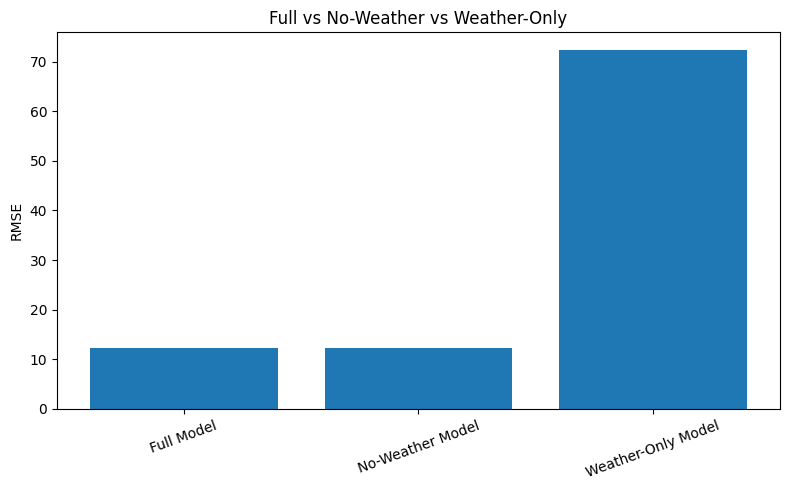

In [19]:
# RMSE comparison

plt.figure(figsize=(8, 5))
plt.bar(weather_comparison_df["Model"], weather_comparison_df["RMSE"])
plt.title("Full vs No-Weather vs Weather-Only")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

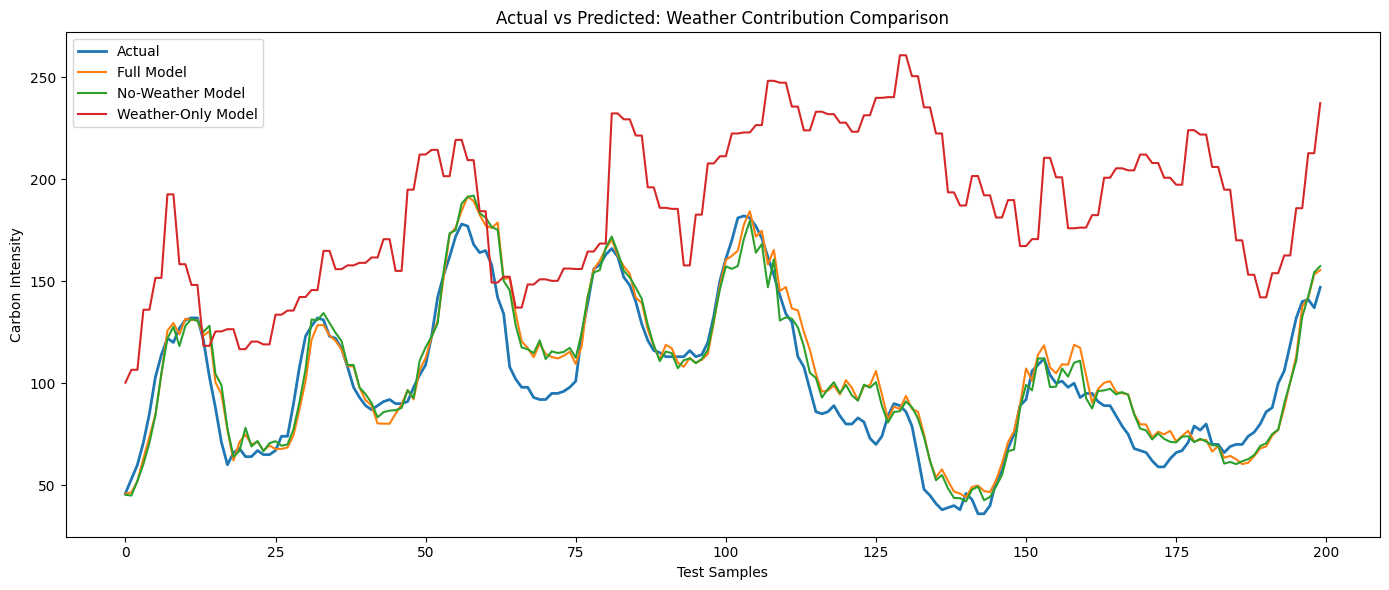

In [20]:
# Actual vs Predictions

plt.figure(figsize=(14, 6))
plt.plot(y_test.values[:200], label="Actual", linewidth=2)
plt.plot(full_preds[:200], label="Full Model")
plt.plot(no_weather_preds[:200], label="No-Weather Model")
plt.plot(weather_only_preds[:200], label="Weather-Only Model")

plt.title("Actual vs Predicted: Weather Contribution Comparison")
plt.xlabel("Test Samples")
plt.ylabel("Carbon Intensity")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Feature importance for full model

full_importance = pd.Series(
    full_model.feature_importances_,
    index=X_full_train.columns
).sort_values(ascending=False)

print(full_importance.head(15))

carbon_roll_24h     1069
doy_cos              994
doy_sin              967
fossil_gas           912
nuclear              833
wind_offshore        807
wind_onshore         785
fossil_hard_coal     770
pressure_msl_hpa     656
other                647
carbon_roll_168h     638
solar                631
hour_sin             575
biomass              567
hour_cos             540
dtype: int32


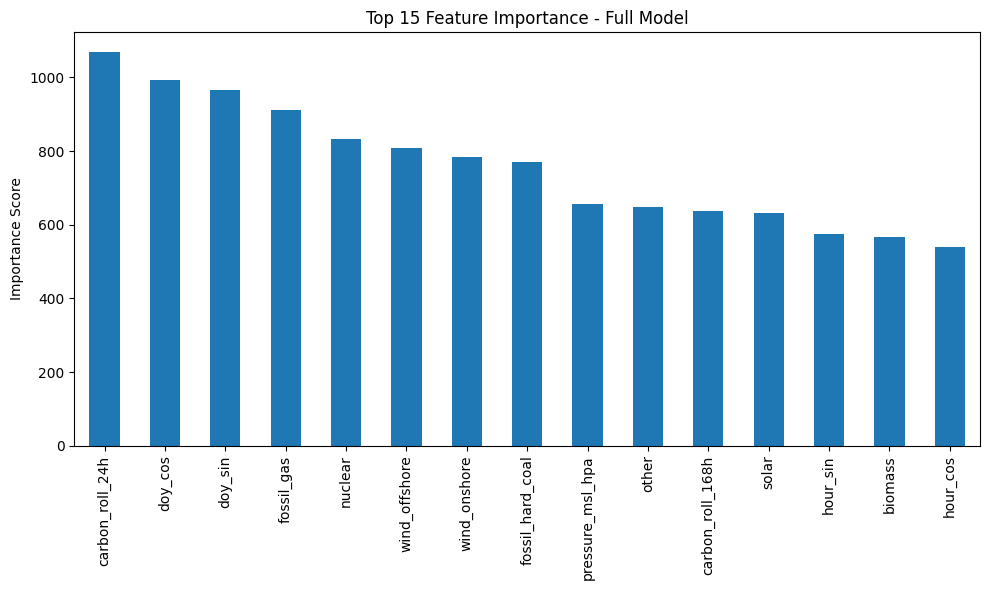

In [22]:
# Full model feature importance

plt.figure(figsize=(10, 6))
full_importance.head(15).plot(kind="bar")

plt.title("Top 15 Feature Importance - Full Model")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [23]:
weather_comparison_df.to_csv("../models/weather_feature_comparison.csv", index=False)

print("Weather comparison results saved.")

Weather comparison results saved.


In [25]:
weather_preds_df = pd.DataFrame({
    "actual": y_test.values,
    "full_model": full_preds,
    "no_weather_model": no_weather_preds,
    "weather_only_model": weather_only_preds
})

weather_preds_df.to_csv("../models/weather_feature_predictions.csv", index=False)

print("Weather prediction outputs saved.")

Weather prediction outputs saved.
